<a href="https://colab.research.google.com/github/shaalu2408-pixel/Python-coding-challenges/blob/main/Shalini_R_day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Day 10 – Final Integration**


# **Dataset description**

The Titanic datasets provides information about the travelled Passenger and who are all Survived, Name, Age, Sex, Sibsp, Parch, Ticket rate, Fare Amount, Cabin travelled, Pclass and Embarked Details.The target variable is Survived, where 1 indicates the passenger survived and 0 indicates they did not. some columns such as Age, Cabin and Embarked contain missing values that require cleaning before analysis.

# **Data cleaning:**

1) Checked for the number of missing values in each column of the “Titanic Dataset” table.

2) Filled the missing values of ‘Embarked’,'Age"and ‘Cabin’ with its Mean, mode or average  to the
nearest integer by statistical analysis method

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import requests
from bs4 import BeautifulSoup as bs


In [2]:
df = pd.read_csv("/content/Titanic dataset.csv")
print("Dataset Loaded Successfully ")
print(df.head())

Dataset Loaded Successfully 
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [3]:
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())


Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
Embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(Embarked_mode, inplace=True)
Cabin_mode = df['Cabin'].mode()[0]
df['Cabin'].fillna(Cabin_mode,inplace=True)
df['Age'].fillna(df['Age'].mean(),inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


/tmp/ipython-input-4163628502.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(Embarked_mode, inplace=True)
/tmp/ipython-input-4163628502.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

# **Data Transformation:**

1.Splitted the ‘Names’ column in the “Titanic dataset” Table into 3 meaningful columns:
‘Title’, ‘First Name’, and ‘Last Name’.


2.Checked for inconsistencies in the columns and propose
corrective actions if necessary. # New Section

3.Explored series & columns.

4.Setted a custom index and sort.


In [5]:
df['Last_Name'] = df['Name'].str.split(',').str[0]
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')[0].str.strip()
df['First_Name'] = df['Name'].str.split('.').str[-1].str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
 12  Last_Name    891 non-null    object 
 13  Title        891 non-null    object 
 14  First_Name   891 non-null    object 
dtypes: float64(2), int64(5), object(8)
memory usage: 104.5+ KB


In [6]:
df.columns          # explore all columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Last_Name', 'Title',
       'First_Name'],
      dtype='object')

In [7]:
df['Fare']           # specific column as a Series

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


In [8]:
df.set_index('PassengerId', inplace=True)               # PassengerID as index
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Last_Name,Title,First_Name
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S,Braund,Mr,Owen Harris
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer)
3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S,Heikkinen,Miss,Laina
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,Futrelle,Mrs,Jacques Heath (Lily May Peel)
5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S,Allen,Mr,William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B96 B98,S,Montvila,Rev,Juozas
888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,Graham,Miss,Margaret Edith
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B96 B98,S,Johnston,Miss,"Catherine Helen ""Carrie"""


In [9]:
df.sort_values(by='Age', inplace=True)              # sorting Age column in ascending order
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Last_Name,Title,First_Name
PassengerId,,,,,,,,,,,,,,
804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,B96 B98,C,Thomas,Master,Assad Alexander
756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,B96 B98,S,Hamalainen,Master,Viljo
470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,B96 B98,C,Baclini,Miss,Helene Barbara
645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,B96 B98,C,Baclini,Miss,Eugenie
79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,B96 B98,S,Caldwell,Master,Alden Gates
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,0,3,"Connors, Mr. Patrick",male,70.50,0,0,370369,7.7500,B96 B98,Q,Connors,Mr,Patrick
494,0,1,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,B96 B98,C,Artagaveytia,Mr,Ramon
97,0,1,"Goldschmidt, Mr. George B",male,71.00,0,0,PC 17754,34.6542,A5,C,Goldschmidt,Mr,George B


# **Data Exploration & Wrangling**

1) Explored dataset: head(), tail(), info(), describe(),
value_counts().

In [10]:
print("\n Head: \n",df.head)
print("\n Tail: \n",df.tail)


 Head: 
 <bound method NDFrame.head of              Survived  Pclass                                  Name     Sex  \
PassengerId                                                                   
804                 1       3       Thomas, Master. Assad Alexander    male   
756                 1       2             Hamalainen, Master. Viljo    male   
470                 1       3         Baclini, Miss. Helene Barbara  female   
645                 1       3                Baclini, Miss. Eugenie  female   
79                  1       2         Caldwell, Master. Alden Gates    male   
...               ...     ...                                   ...     ...   
117                 0       3                  Connors, Mr. Patrick    male   
494                 0       1               Artagaveytia, Mr. Ramon    male   
97                  0       1             Goldschmidt, Mr. George B    male   
852                 0       3                   Svensson, Mr. Johan    male   
631         

In [11]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df.value_counts()

Survived  Pclass  Name                                             Sex     Age        SibSp  Parch  Ticket       Fare      Cabin    Embarked  Last_Name     Title  First_Name                       
1         3       de Mulder, Mr. Theodore                          male    30.000000  0      0      345774       9.5000    B96 B98  S         de Mulder     Mr     Theodore                             1
0         1       Allison, Miss. Helen Loraine                     female  2.000000   1      2      113781       151.5500  C22 C26  S         Allison       Miss   Helen Loraine                        1
                  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female  25.000000  1      2      113781       151.5500  C22 C26  S         Allison       Mrs    Hudson J C (Bessie Waldo Daniels)    1
                  Andrews, Mr. Thomas Jr                           male    39.000000  0      0      112050       0.0000    A36      S         Andrews       Mr     Thomas Jr                            1
                  Artagaveytia, Mr. Ramon                          male    71.000000  0      0      PC 17609     49.5042   B96 B98  C         Artagaveytia  Mr     Ramon                                1
                                                                                                                                                                                                       ..
                  Colley, Mr. Edward Pomeroy                       male    47.000000  0      0      5727         25.5875   E58      S         Colley        Mr     Edward Pomeroy                       1
                  Clifford, Mr. George Quincy                      male    29.699118  0      0      110465       52.0000   A14      S         Clifford      Mr     George Quincy                        1
                  Chaffee, Mr. Herbert Fuller                      male    46.000000  1      0      W.E.P. 5734  61.1750   E31      S         Chaffee       Mr     Herbert Fuller                       1
                  Cavendish, Mr. Tyrell William                    male    36.000000  1      0      19877        78.8500   C46      S         Cavendish     Mr     Tyrell William                       1
                  Carrau, Mr. Francisco M                          male    28.000000  0      0      113059       47.1000   B96 B98  S         Carrau        Mr     Francisco M                          1
Name: count, Length: 891, dtype: int64

2. Merge, concat, join datasets and Group by and aggregate data.

In [13]:
df1 = df[['Survived','Pclass']].head(5)               # merge
df2 = df[['Fare','Age','Pclass']].head(5)
pd.merge(df1,df2,on = 'Pclass',how = 'inner')

,Survived,Pclass,Fare,Age
0,1,3,8.5167,0.42
1,1,3,19.2583,0.75
2,1,3,19.2583,0.75
3,1,2,14.5000,0.67
4,1,2,29.0000,0.83
5,1,3,8.5167,0.42
6,1,3,19.2583,0.75
7,1,3,19.2583,0.75
8,1,3,8.5167,0.42
9,1,3,19.2583,0.75


In [14]:
df1 = df.iloc[:5]                             #concatenation
df2 = df.iloc[5:10]
concat_df = pd.concat([df1,df2])
print(concat_df.shape)

(10, 14)


In [15]:
df1 = df[['Age','Survived']].head(5)          #Joins
df2 = df[['Pclass','Fare']].head(5)
joined_df = df1.join(df2)
joined_df

,Age,Survived,Pclass,Fare
PassengerId,,,,
804,0.42,1,3,8.5167
756,0.67,1,2,14.5000
470,0.75,1,3,19.2583
645,0.75,1,3,19.2583
79,0.83,1,2,29.0000


In [16]:
df.groupby('Sex')['Age'].mean()

,Age
Sex,
female,28.216730
male,30.505824


In [17]:
df.groupby('Sex')['Age'].agg(['mean','min','max','count'])

,mean,min,max,count
Sex,,,,
female,28.216730,0.75,63.0,314
male,30.505824,0.42,80.0,577


# **Analysis & Visualization:**

# **Matplotlib Visualization**

 1.Created a Line chart to visualize the Parch rate by Embarked.

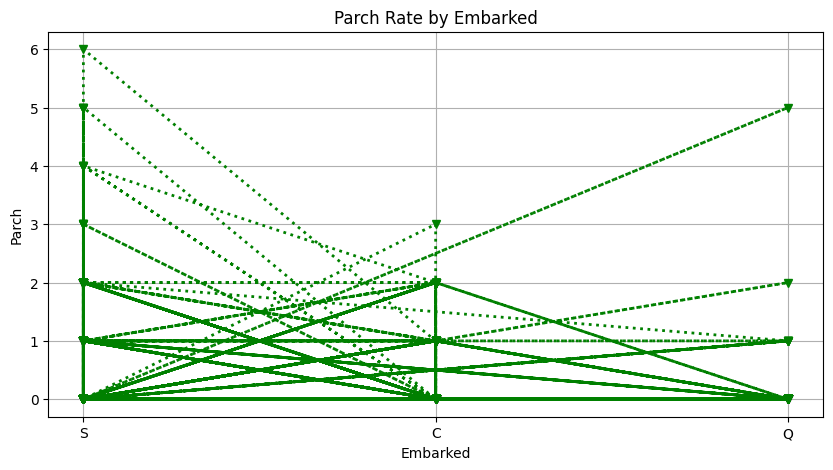

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Embarked'],df['Parch'],linewidth=2,linestyle=':',color='g',marker='v',alpha=1.0)
plt.title('Parch Rate by Embarked')
plt.xlabel('Embarked')
plt.ylabel('Parch')
plt.grid(True)

plt.show()

2.Plotted a Scatter Plot between "Age" and "Fare".

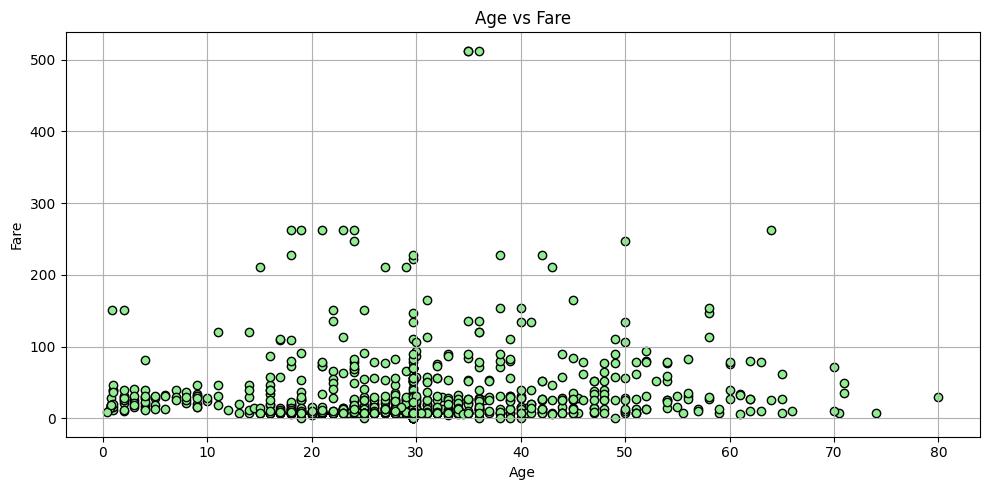

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(df.Age,df.Fare,color='lightgreen',edgecolor= 'black',marker='o',alpha=1.0)
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True)
plt.tight_layout()
plt.show()

3.Created a Bar Chart to visualize the "Fare rate count by title".

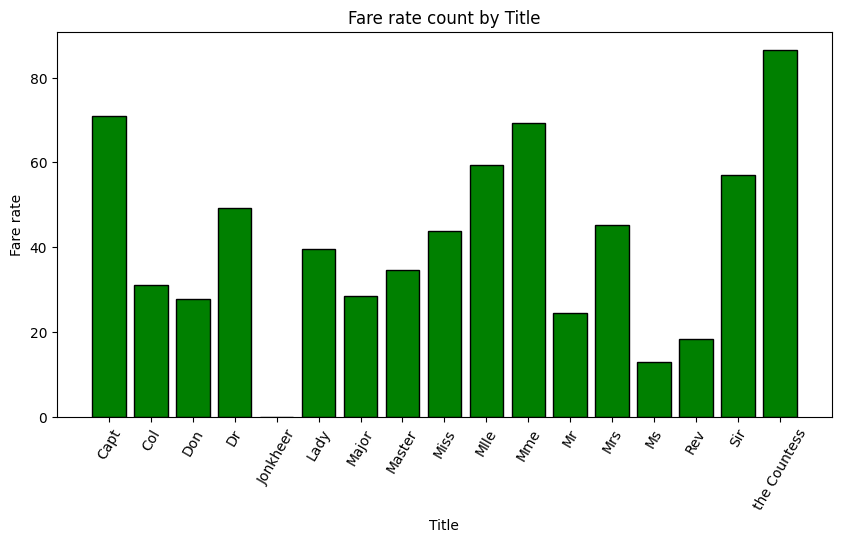

In [ ]:
cost=df.groupby("Title")["Fare"].mean().reset_index()
plt.figure(figsize=(10,5))
plt.bar(cost.Title,cost.Fare,color='g',edgecolor='black',alpha=1.0)
plt.title('Fare rate count by Title')
plt.xlabel('Title')
plt.xticks(rotation=60)
plt.ylabel('Fare rate')
plt.show()

4.Created a Pie Chart to "Distribution of Embarked based on the Pclass".

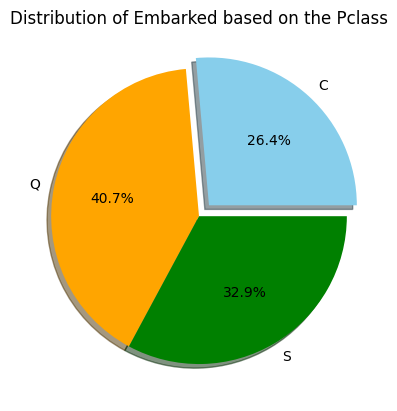

In [ ]:
cwm = df.groupby('Embarked')['Pclass'].mean().reset_index()
plt.pie(cwm.Pclass,
        labels=cwm.Embarked,
        colors=['skyblue','orange','green'],
        autopct="%1.1f%%",
        explode=[0.1,0,0],
        shadow=True
        )
plt.title('Distribution of Embarked based on the Pclass')
plt.show()

5.Finded Histogram for "Distribution of Passenger Fare".


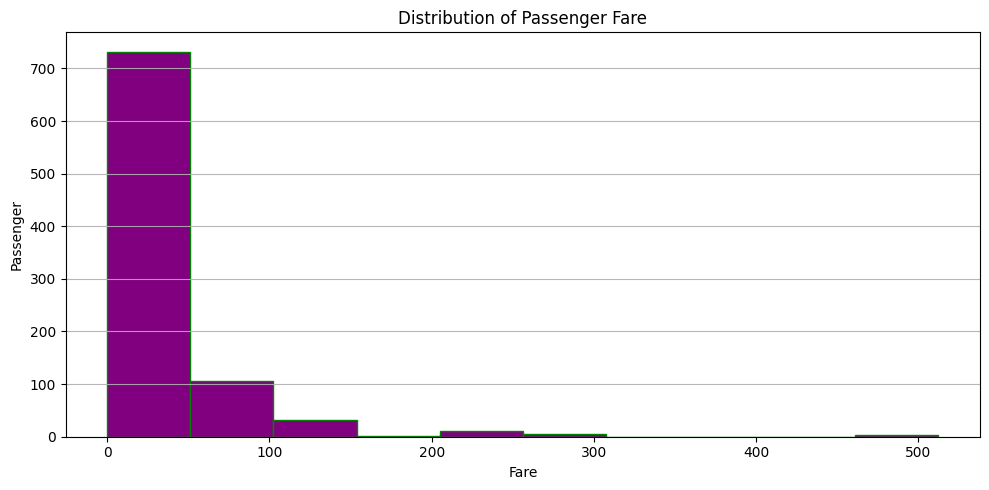

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df['Fare'],bins=10,color='purple',edgecolor='g')
plt.title('Distribution of Passenger Fare')
plt.xlabel('Fare')
plt.ylabel('Passenger')
plt.grid(axis='y',linestyle='-',alpha=0.9)
plt.tight_layout()
plt.show()

6.Plotted a Box Plot of Passengers Fare.

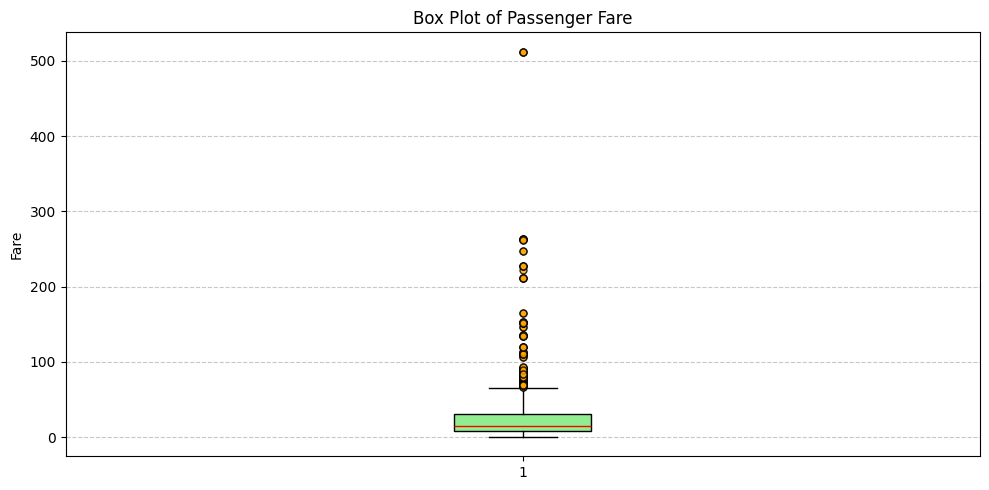

In [ ]:
plt.figure(figsize=(10,5))
plt.boxplot(df['Fare'],patch_artist=True,
            boxprops=dict(facecolor='lightgreen',color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o',markerfacecolor='orange',markersize=5,alpha=0.8))
plt.title('Box Plot of Passenger Fare')
plt.ylabel('Fare')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

#  Seaborn & Plotly Advanced Visualization

1.Created a "Heatmap" and "Pair plot" for Numerical columns in the given dataset

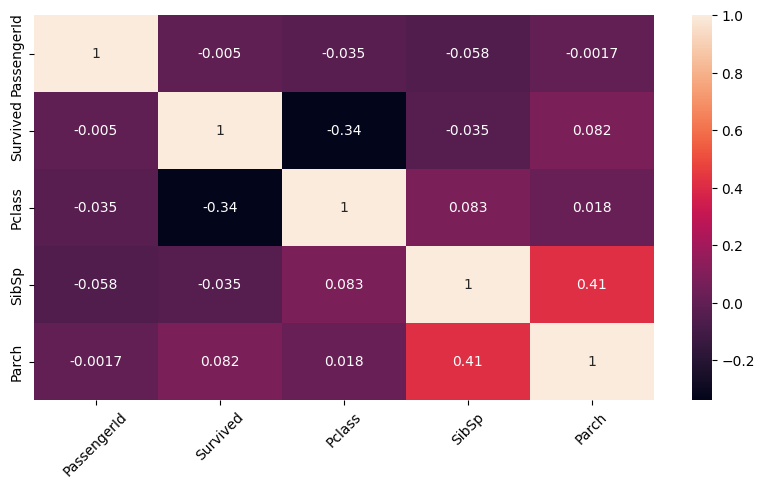

In [ ]:
ncol=df.select_dtypes('n').columns
corr_matrix = df[ncol].corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix,annot=True)
plt.xticks(rotation=45)
plt.show()

2.Created a "Violin Chart" between Pclass and Parch by Survived.

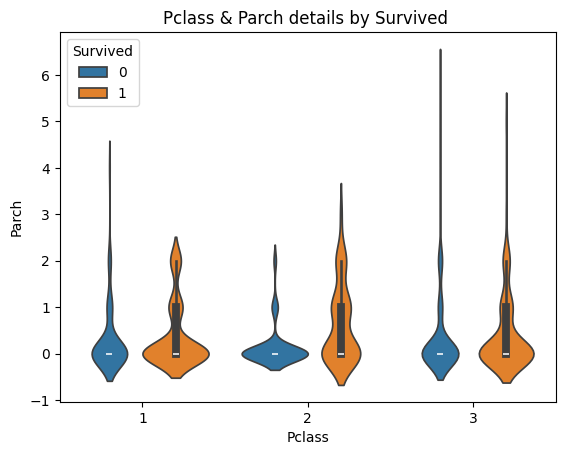

In [ ]:
sns.violinplot(x='Pclass',y='Parch',hue='Survived',data=df)
plt.title('Pclass & Parch details by Survived ')
plt.show()

3.Plot a Swarm Plot for "Fare rate by embarked".

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 32.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


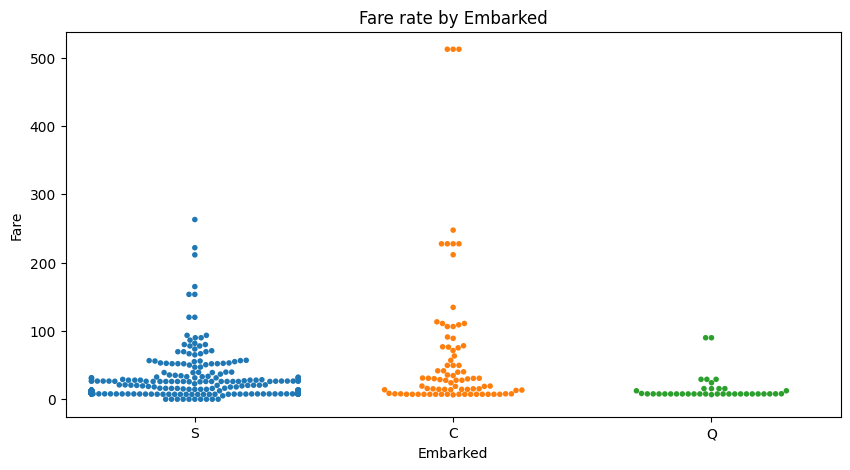

In [ ]:
subset_df=df.sample(400)
plt.figure(figsize=(10,5))
sns.swarmplot(data=subset_df,x='Embarked',y='Fare',hue='Embarked',size=4)
plt.title('Fare rate by Embarked')
plt.show()

4.Plotted a Density plot for "Agewise Pclass category".

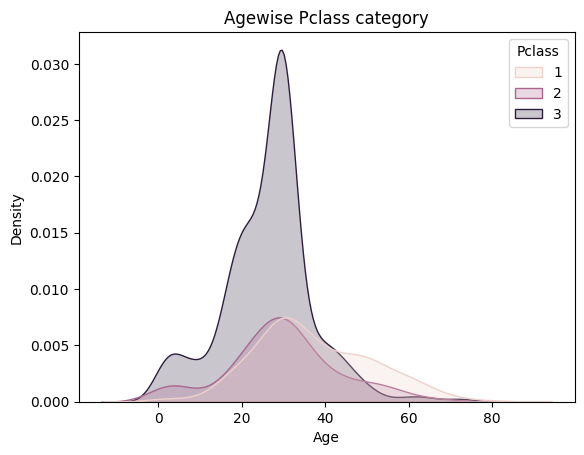

In [ ]:
#kde density plot
sns.kdeplot(
    x='Age',
    hue='Pclass',
    fill=True,
    data=df,
    bw_adjust=1
)
plt.title('Agewise Pclass category')
plt.show()

5.Finded Interactive Plotly charts (scatter, bar, line) based on "Gender" category with "Age","Fare","pclass".

In [ ]:
import plotly.express as px
figure = px.scatter(df,x='Age',y='Fare',color='Sex',title='Scatter plot for Age vs Gender')
figure.show()
figure=px.bar(df,x='Pclass',y='Fare',color='Sex',title='Bar Chart for Pclass and Gender')
figure.show()
figure=px.line(df,x='Age',y='Fare',color='Sex',title='Line Chart for Age and Gender')
figure.show()

# **Introduction to Web Scraping & AI**

In [18]:
!pip install requests
!pip install bs4

In [19]:
import requests
from bs4 import BeautifulSoup as bs

In [20]:
url= 'https://en.wikipedia.org/wiki/List_of_tallest_buildings_in_Chennai'
headers={
    "User-Agent": "Mozilla/5.0 (windows NT 10.0; Win64; x64)"
                   "Applewebkit/537.36(KHTML, like Gecko)"
                   "Chromr/120.0.0.0 Safari/537.36"
}
response = requests.get(url, headers=headers)
response

<Response [200]>

In [21]:
html_code=response.text
soup = bs(html_code,'html.parser')

In [22]:
table = soup.find('table')                  #extract Table
print(table)
title = soup.find('h1').text               #extract Title
title

<table class="wikitable sortable">
<caption>
</caption>
<tbody><tr style="background:#ececec;">
<th>Rank
</th>
<th>Name
</th>
<th>Image
</th>
<th>Locale
</th>
<th>Height
</th>
<th>Floors
</th>
<th>Building type
</th>
<th>Year
</th></tr>
<tr>
<th>1
</th>
<td><a href="/wiki/SPR_Highliving_District_Towers" title="SPR Highliving District Towers">Highliving District Tower-H—SPR City</a><sup class="reference" id="cite_ref-Dinamalar_45StoriedTower_4-1"><a href="#cite_note-Dinamalar_45StoriedTower-4"><span class="cite-bracket">[</span>4<span class="cite-bracket">]</span></a></sup><sup class="reference" id="cite_ref-15"><a href="#cite_note-15"><span class="cite-bracket">[</span>15<span class="cite-bracket">]</span></a></sup> Luxury collection PRESIDENTIAL APARTMENTS
</td>
<td><span typeof="mw:File/Frameless"><a class="mw-file-description" href="/wiki/File:SPR_City,_Chennai_-_22_December_2021.jpg"><img class="mw-file-element" data-file-height="3264" data-file-width="2448" decoding="async" height

'List of tallest buildings in Chennai'

In [23]:
headers = table.find('tr').text.split('\n')
headers

['',
 'Rank',
 '',
 'Name',
 '',
 'Image',
 '',
 'Locale',
 '',
 'Height',
 '',
 'Floors',
 '',
 'Building type',
 '',
 'Year',
 '']

In [24]:
df.to_csv('tallest_buildings_chennai.csv',index=False)

In [25]:
df=pd.read_csv('/content/Titanic dataset.csv')
df1=pd.read_csv('/content/tallest_buildings_chennai.csv')


# **Merge Datasets**

In [26]:
merged_df = pd.concat([df,df1]),
ignore_index= True
merged_df

(     PassengerId  Survived  Pclass  \
 0            1.0         0       3   
 1            2.0         1       1   
 2            3.0         1       3   
 3            4.0         1       1   
 4            5.0         0       3   
 ..           ...       ...     ...   
 886          NaN         0       3   
 887          NaN         0       1   
 888          NaN         0       1   
 889          NaN         0       3   
 890          NaN         1       1   
 
                                                   Name     Sex   Age  SibSp  \
 0                              Braund, Mr. Owen Harris    male  22.0      1   
 1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
 2                               Heikkinen, Miss. Laina  female  26.0      0   
 3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
 4                             Allen, Mr. William Henry    male  35.0      0   
 ..                                               

# **Insights & recommendations**

**Insights**

1. Survival Rate

Overall survival rate ≈ 38%.
Most passengers did not survive.

2. Gender Impact

Females: ~74% survived.

Males: ~19% survived.
→ Women were prioritized during evacuation ("women and children first" policy).

3. Class Differences

1st Class: ~63% survived

2nd Class: ~47% survived

3rd Class: ~24% survived
→ Wealthier passengers had a much higher chance of survival.

4. Age Factor

Children (<15 years): Higher survival rates (~50%)

Elderly (>50 years): Lower survival rates (~25%)
→ Younger passengers were more likely to be saved.

5. Embarkation Point

Cherbourg (C): Highest survival rate (~55%)

Southampton (S): Lowest (~34%)




**Recommendations**

1.Preprocess (handle missing values, encode categorical features).

2.Feature engineer (FamilySize, IsAlone, Title, etc.).

3.Model with Logistic Regression, Random Forest, or XGBoost.

4.Evaluate with accuracy, precision, recall, ROC-AUC.

GitHub Link: https://github.com/shaalu2408-pixel/Python-coding-challenges